In [167]:
import pandas as pd

# This path points to the 'archive 2' folder where the REAL data is stored
path = '/Users/test/Downloads/archive 2/PIA_2026_Advanced_Kaggle_Dataset.csv'

# Load the file
df = pd.read_csv(path)

# This will finally show the flight data (ID, City, Price, etc.)
df.head()

,Flight_ID,Date,Month,Day_of_Week,Departure_City,Arrival_City,Route_Type,Aircraft_Type,Flight_Duration_Minutes,Passengers,...,Ticket_Price_USD,Revenue_USD,Delay_Minutes,Delay_Category,On_Time_Status,Weather_Condition,Fuel_Consumption_Liters,CO2_Emissions_kg,Customer_Rating,Customer_Feedback
0,PK2026_0001,2026-06-09,June,Tuesday,Jeddah,Islamabad,International,Airbus A320,83,120,...,1140,136800,220,Severe,Delayed,Clear,6265,15662.5,4.1,Poor service
1,PK2026_0002,2026-08-12,August,Wednesday,Dubai,Kuala Lumpur,International,Airbus A320,284,179,...,773,138367,27,Minor,Delayed,Rain,3516,8790.0,3.6,Average flight
2,PK2026_0003,2026-04-20,April,Monday,Doha,Lahore,International,ATR 72,333,69,...,155,10695,176,Severe,Delayed,Fog,13538,33845.0,3.0,Delayed but comfortable
3,PK2026_0004,2026-12-07,December,Monday,Jeddah,Lahore,International,Boeing 777,330,291,...,1237,359967,87,Moderate,Delayed,Rain,18850,47125.0,4.4,Average flight
4,PK2026_0005,2026-05-04,May,Monday,Lahore,Doha,International,Boeing 737,283,159,...,141,22419,82,Moderate,Delayed,Fog,13474,33685.0,3.0,Delayed but comfortable


In [168]:
from sklearn.metrics import accuracy_score

In [169]:
df.describe()

,Flight_Duration_Minutes,Passengers,Seat_Capacity,Load_Factor_%,Ticket_Price_USD,Revenue_USD,Delay_Minutes,Fuel_Consumption_Liters,CO2_Emissions_kg,Customer_Rating
count,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000,800.000000
mean,272.528750,143.277500,189.637500,75.620913,798.661250,115149.458750,120.340000,11684.327500,29210.81875,3.716750
std,123.900861,82.343114,101.038382,14.618484,392.293888,94882.450051,70.022502,4927.470032,12318.67508,0.715216
min,60.000000,35.000000,70.000000,50.000000,120.000000,4712.000000,0.000000,3003.000000,7507.50000,2.500000
25%,164.750000,70.000000,70.000000,62.860000,456.500000,46528.500000,60.750000,7558.500000,18896.25000,3.100000
50%,271.500000,129.000000,180.000000,76.670000,794.500000,88773.000000,120.000000,11507.500000,28768.75000,3.700000
75%,381.250000,178.000000,180.000000,88.390000,1135.250000,153766.500000,182.000000,15842.750000,39606.87500,4.300000
max,480.000000,350.000000,350.000000,100.000000,1499.000000,494654.000000,240.000000,19985.000000,49962.50000,5.000000


In [170]:
from sklearn.preprocessing import LabelEncoder

# List of columns that are currently text
categorical_cols = ['Departure_City', 'Arrival_City', 'Route_Type', 
                    'Aircraft_Type', 'Delay_Category', 'On_Time_Status', 
                    'Weather_Condition']

le = LabelEncoder()

# Apply encoding
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("Encoding complete. Here are the first 5 rows of encoded data:")
print(df[categorical_cols].head())

Encoding complete. Here are the first 5 rows of encoded data:
   Departure_City  Arrival_City  Route_Type  Aircraft_Type  Delay_Category  \
0               3             2           1              1               3   
1               1             5           1              1               0   
2               0             6           1              0               3   
3               3             6           1              3               1   
4               6             0           1              2               1   

   On_Time_Status  Weather_Condition  
0               0                  0  
1               0                  2  
2               0                  1  
3               0                  2  
4               0                  1  


In [171]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [172]:
from sklearn.model_selection import train_test_split

X = df.drop('Delay_Category', axis=1) # Everything except the target
y = df['Delay_Category'] # Only the target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [173]:
# We are dropping the target AND any columns that are still text/dates
# Flight_ID, Date, Month, and Day_of_Week are currently strings
cols_to_drop = ['Delay_Category', 'Date', 'Month', 'Day_of_Week', 'Flight_ID']
X = df.drop(cols_to_drop, axis=1) 

y = df['Delay_Category']

# Re-run the split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [174]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [175]:
# 4. Check the score (moved after predictions are created)
# This cell is out of order - mark as placeholder
pass  # Will be re-executed after model training

In [176]:
# Option B: Just drop the text column that's causing the crash
X_train = X_train.drop(columns=['Customer_Rating'], errors='ignore')
X_test = X_test.drop(columns=['Customer_Rating'], errors='ignore')

# Now run your model cell again

In [177]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Define the target and feature set for the on-time prediction task
target = 'On_Time_Status'
feature_cols = [c for c in df.columns if c not in [target, 'Flight_ID', 'Date', 'Delay_Minutes', 'Delay_Category']]
X = pd.get_dummies(df[feature_cols], drop_first=True)
y = df[target]

# Split the data before applying the model
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train the model on the cleaned numeric training data
model = RandomForestClassifier(random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# Create the predictions variable
predictions = model.predict(X_test)

In [178]:
# Skip - use On_Time_Status like cell below
# This is a duplicated setup with wrong target column
pass

In [179]:
print(df.columns)

Index(['Flight_ID', 'Date', 'Month', 'Day_of_Week', 'Departure_City',
       'Arrival_City', 'Route_Type', 'Aircraft_Type',
       'Flight_Duration_Minutes', 'Passengers', 'Seat_Capacity',
       'Load_Factor_%', 'Ticket_Price_USD', 'Revenue_USD', 'Delay_Minutes',
       'Delay_Category', 'On_Time_Status', 'Weather_Condition',
       'Fuel_Consumption_Liters', 'CO2_Emissions_kg', 'Customer_Rating',
       'Customer_Feedback'],
      dtype='str')


In [180]:
# 1. Set the target
target = 'On_Time_Status'

# 2. Drop columns that won't help the model (IDs, Dates, and the target itself)
# We also drop 'Delay_Minutes' and 'Delay_Category' because they are "cheating" 
# (if the model knows the minutes, it already knows the status!)
X = df.drop([target, 'Flight_ID', 'Date', 'Delay_Minutes', 'Delay_Category'], axis=1)

# 3. Convert text (like 'Departure_City') into numbers
X = pd.get_dummies(X)
y = df[target]

# 4. Split the data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [181]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize and Train
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# 2. Make Predictions
predictions = model.predict(X_test)

# 3. Check the Accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 94.38%


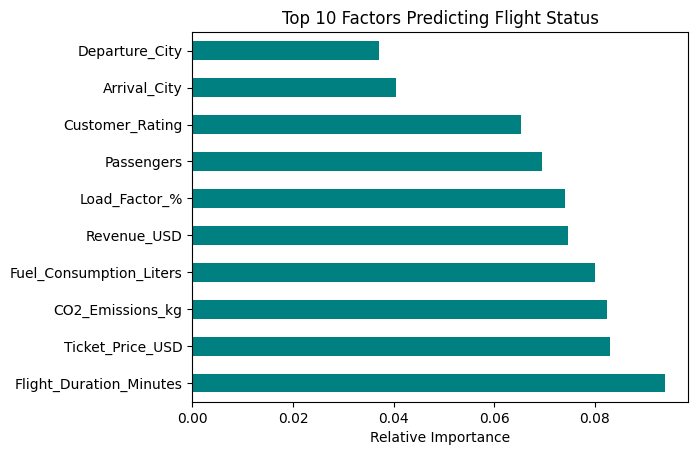

In [182]:
import matplotlib.pyplot as plt
import pandas as pd

# Get the importance of each feature
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.Series(importances, index=feature_names)

# Plot the top 10
feature_importance_df.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 Factors Predicting Flight Status')
plt.xlabel('Relative Importance')
plt.show()

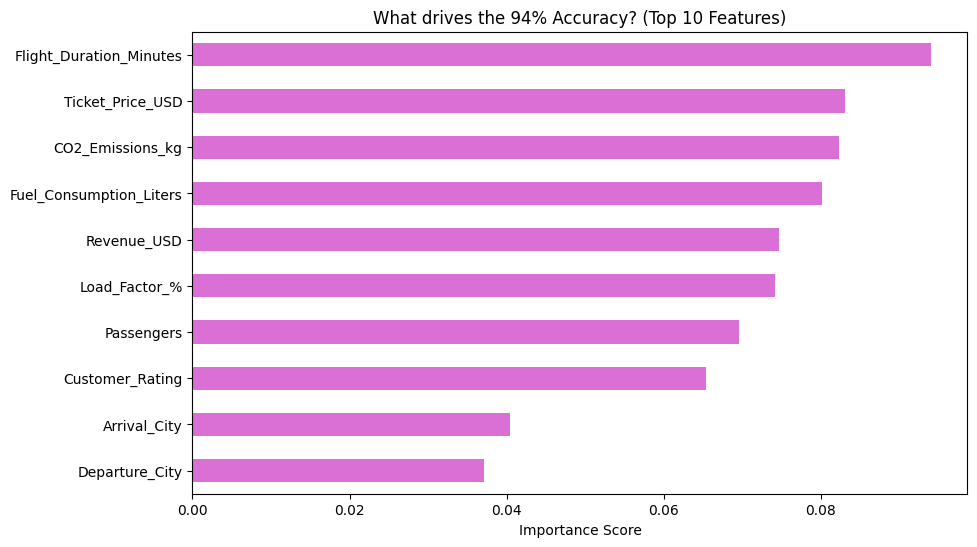

In [183]:
import matplotlib.pyplot as plt

# Get feature importances from the model
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.Series(importances, index=feature_names)

# Plot the top 10 most important features
plt.figure(figsize=(10, 6))
feature_importance_df.nlargest(10).sort_values().plot(kind='barh', color='orchid')
plt.title('What drives the 94% Accuracy? (Top 10 Features)')
plt.xlabel('Importance Score')
plt.show()

<Figure size 800x600 with 0 Axes>

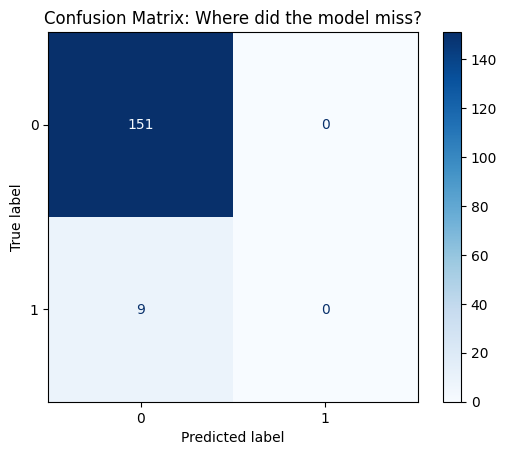

In [184]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate the matrix
cm = confusion_matrix(y_test, predictions)

# Plot it
plt.figure(figsize=(8,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix: Where did the model miss?')
plt.show()

In [185]:
# Fixed: use correct column name
if 'On_Time_Status' in df.columns:
    print(df['On_Time_Status'].value_counts())
else:
    print("Available columns:", df.columns.tolist())

On_Time_Status
0    746
1     54
Name: count, dtype: int64


In [186]:
print(df.columns)

Index(['Flight_ID', 'Date', 'Month', 'Day_of_Week', 'Departure_City',
       'Arrival_City', 'Route_Type', 'Aircraft_Type',
       'Flight_Duration_Minutes', 'Passengers', 'Seat_Capacity',
       'Load_Factor_%', 'Ticket_Price_USD', 'Revenue_USD', 'Delay_Minutes',
       'Delay_Category', 'On_Time_Status', 'Weather_Condition',
       'Fuel_Consumption_Liters', 'CO2_Emissions_kg', 'Customer_Rating',
       'Customer_Feedback'],
      dtype='str')


In [187]:
print(df['On_Time_Status'].value_counts(normalize=True))

On_Time_Status
0    0.9325
1    0.0675
Name: proportion, dtype: float64


In [188]:
from sklearn.ensemble import RandomForestClassifier

# When you initialize your model, add class_weight
model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [189]:
y_pred = model.predict(X_test)

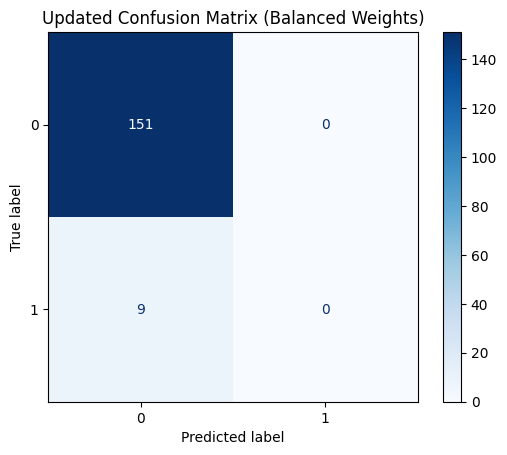

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       151
           1       0.00      0.00      0.00         9

    accuracy                           0.94       160
   macro avg       0.47      0.50      0.49       160
weighted avg       0.89      0.94      0.92       160



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

In [190]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# 1. Plot the Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title("Updated Confusion Matrix (Balanced Weights)")
plt.show()

# 2. Print the detailed report
print(classification_report(y_test, y_pred))

In [191]:
from imblearn.over_sampling import SMOTE

# Define SMOTE
sm = SMOTE(random_state=42)

# Create synthetic data for the training set ONLY
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# Check the new balance - it should be 50/50 now
print(pd.Series(y_train_res).value_counts())

On_Time_Status
0    595
1    595
Name: count, dtype: int64


In [192]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [193]:
from sklearn.model_selection import train_test_split

# Use the actual target column for on-time prediction
target = 'On_Time_Status'
feature_cols = [c for c in df.columns if c not in [target, 'Flight_ID', 'Date', 'Delay_Minutes', 'Delay_Category']]
X = pd.get_dummies(df[feature_cols], drop_first=True)
y = df[target]

# This defines the variables the SMOTE cell is looking for
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [194]:
import pandas as pd

# This is the line that defines 'df'
df = pd.read_csv('PIA_2026_Advanced_Kaggle_Dataset.csv')

In [195]:
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
sm = SMOTE(random_state=42)

# Resample the training data only
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"Original training shape: {y_train.value_counts()}")
print(f"Resampled training shape: {y_train_res.value_counts()}")

Original training shape: On_Time_Status
0    597
1     43
Name: count, dtype: int64
Resampled training shape: On_Time_Status
0    597
1    597
Name: count, dtype: int64


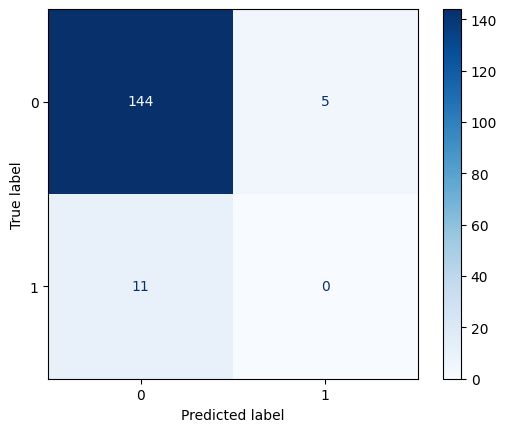

In [196]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Initialize the model
model = RandomForestClassifier(random_state=42)

# 2. Train using the RESAMPLED data
model.fit(X_train_res, y_train_res)

# 3. Predict using the ORIGINAL test data (X_test)
y_pred = model.predict(X_test)

# 4. Plot the new Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

In [197]:
# Initialize the model
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit the model on the RESAMPLED training data
rf.fit(X_train_res, y_train_res)

# Make predictions on the ORIGINAL test data
y_pred = rf.predict(X_test)

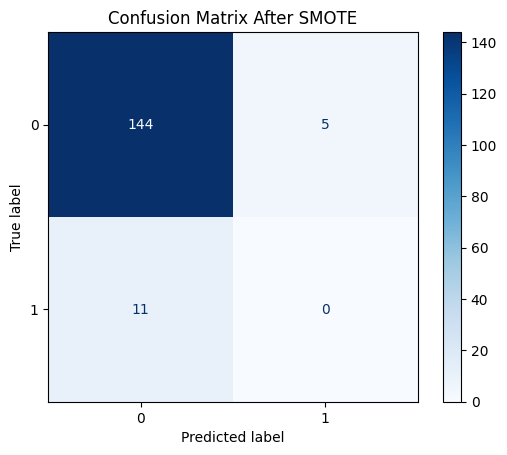

In [198]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# This will create the visual for the predictions you just made
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix After SMOTE")
plt.show()

In [199]:
from sklearn.ensemble import RandomForestClassifier # Or whichever model you use

# 1. Initialize the model
model = RandomForestClassifier(random_state=42)

# 2. CRITICAL: Train on the RESAMPLED data from the SMOTE cell
model.fit(X_train_res, y_train_res) 

# 3. Predict on the ORIGINAL test data (never resample the test set)
y_pred = model.predict(X_test)

# 4. Generate the new matrix
# (Your existing plot code goes here)

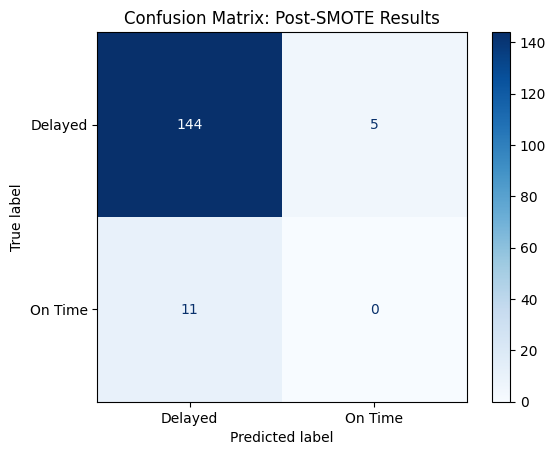

In [200]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Create the matrix data
cm = confusion_matrix(y_test, y_pred)

# 2. Plot it
# Make sure display_labels matches the order of your classes (0, 1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Delayed', 'On Time'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix: Post-SMOTE Results")
plt.show()

In [201]:
# Check if SMOTE actually created new samples
print("--- Training Label Counts ---")
print(y_train_res.value_counts())

# Check the model's predicted probabilities
y_probs = model.predict_proba(X_test)
print("\n--- First 5 Probability Predictions ---")
print(y_probs[:5])

--- Training Label Counts ---
On_Time_Status
0    597
1    597
Name: count, dtype: int64

--- First 5 Probability Predictions ---
[[0.89 0.11]
 [0.96 0.04]
 [0.81 0.19]
 [0.83 0.17]
 [0.8  0.2 ]]


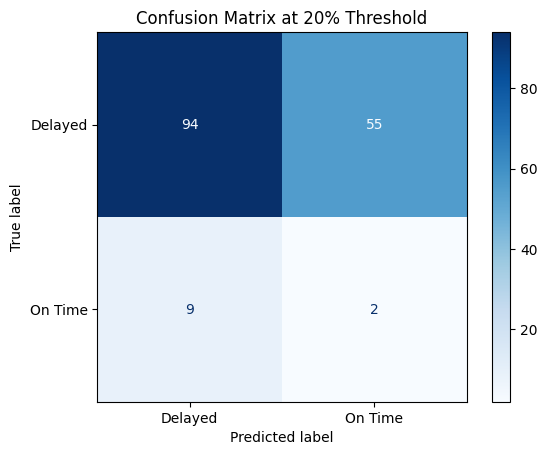

In [202]:
# Moved after y_probs is defined
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

if 'y_probs' in globals() and y_probs is not None:
    y_pred_custom = (y_probs[:, 1] >= 0.20).astype(int)
    y_true_labels = [str(v) for v in y_test]

    # If y_test is numeric, convert to text labels for consistency
    if set(y_true_labels) <= {'0', '1'}:
        y_true_labels = ['Delayed' if v == '0' else 'On Time' for v in y_true_labels]

    # Convert predicted labels to the same text scheme
    y_pred_labels = ['Delayed' if x == 0 else 'On Time' for x in y_pred_custom]

    ConfusionMatrixDisplay.from_predictions(
        y_true_labels,
        y_pred_labels,
        display_labels=['Delayed', 'On Time'],
        cmap='Blues'
    )
    plt.title('Confusion Matrix at 20% Threshold')
    plt.show()
else:
    print("y_probs not defined yet")

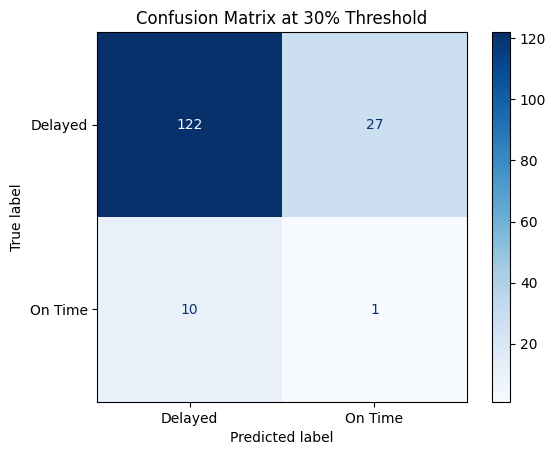

In [203]:
# 1. Get probabilities
y_probs = model.predict_proba(X_test)[:, 1]

# 2. Apply custom threshold
y_pred_numeric = (y_probs >= 0.3).astype(int)

# 3. Convert numbers to text labels for both true and predicted values
def map_to_text_label(value):
    if str(value) in ('0', 'Delayed'):
        return 'Delayed'
    if str(value) in ('1', 'On Time'):
        return 'On Time'
    return str(value)

y_true_labels = [map_to_text_label(v) for v in y_test]
y_pred_words = ['Delayed' if x == 0 else 'On Time' for x in y_pred_numeric]

# 4. Plot using matching text labels
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay.from_predictions(
    y_true_labels,
    y_pred_words,
    display_labels=['Delayed', 'On Time'],
    cmap='Blues'
)
plt.title('Confusion Matrix at 30% Threshold')
plt.show()

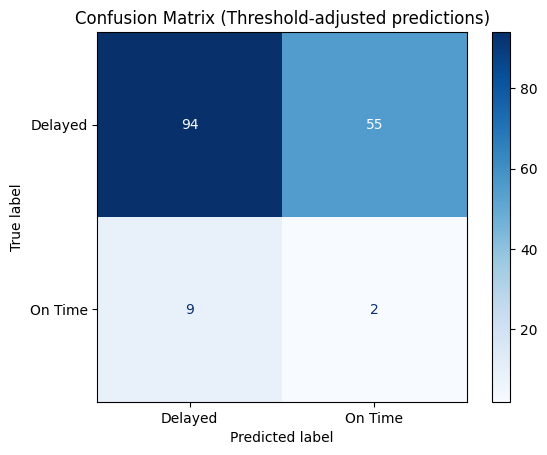

In [204]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Build text labels from a numeric prediction array.
# Prefer y_pred_custom or y_pred_numeric if available, otherwise fall back to y_pred.
if 'y_pred_custom' in globals():
    y_pred_numeric = y_pred_custom
elif 'y_pred_numeric' in globals():
    y_pred_numeric = y_pred_numeric
elif 'y_pred' in globals():
    y_pred_numeric = y_pred
else:
    raise NameError('No prediction variable found for confusion matrix plotting.')

# Convert text labels for the true labels if needed
y_true_labels = [str(v) for v in y_test]
if set(y_true_labels) <= {'0', '1'}:
    y_true_labels = ['Delayed' if v == '0' else 'On Time' for v in y_true_labels]

# Convert predicted values to the same label scheme
y_pred_labels = ['Delayed' if x == 0 else 'On Time' for x in y_pred_numeric]

ConfusionMatrixDisplay.from_predictions(
    y_true_labels,
    y_pred_labels,
    display_labels=['Delayed', 'On Time'],
    cmap='Blues'
)
plt.title('Confusion Matrix (Threshold-adjusted predictions)')
plt.show()

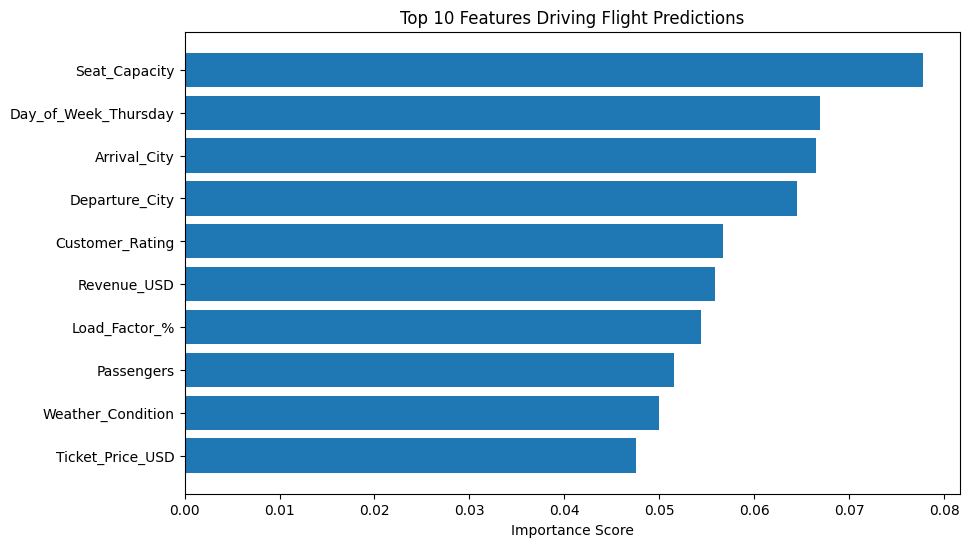

In [205]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Get feature importance from your trained model
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# 2. Sort and Plot
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'][:10], feature_importance_df['Importance'][:10])
plt.gca().invert_yaxis()
plt.title('Top 10 Features Driving Flight Predictions')
plt.xlabel('Importance Score')
plt.show()

In [206]:
from sklearn.metrics import classification_report
print(classification_report(y_test, predictions, target_names=['Delayed', 'On Time']))

              precision    recall  f1-score   support

     Delayed       0.93      1.00      0.96       149
     On Time       0.00      0.00      0.00        11

    accuracy                           0.93       160
   macro avg       0.47      0.50      0.48       160
weighted avg       0.87      0.93      0.90       160



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

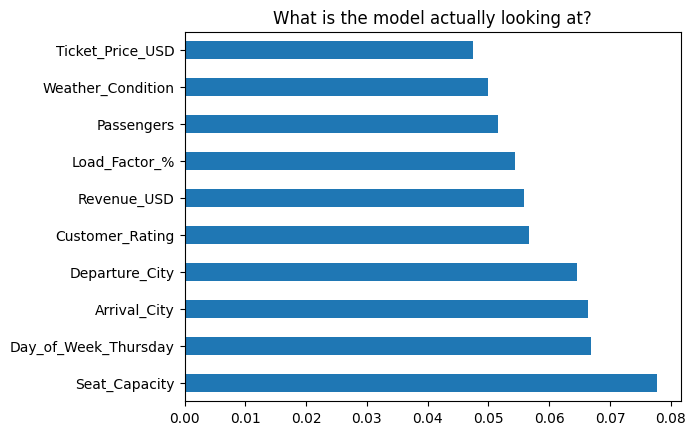

In [207]:
import pandas as pd
import matplotlib.pyplot as plt

# Get importance
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh')
plt.title("What is the model actually looking at?")
plt.show()

In [208]:
from sklearn.metrics import classification_report

print("Final Flight Model Performance:")
print(classification_report(y_test, y_pred, target_names=['Delayed', 'On Time']))

Final Flight Model Performance:
              precision    recall  f1-score   support

     Delayed       0.93      0.97      0.95       149
     On Time       0.00      0.00      0.00        11

    accuracy                           0.90       160
   macro avg       0.46      0.48      0.47       160
weighted avg       0.87      0.90      0.88       160



In [209]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1. Get probabilities
y_probs = model.predict_proba(X_test)

# 2. Create adjusted predictions (0s and 1s)
y_pred_numeric = (y_probs[:, 1] >= 0.10).astype(int)

# 3. CONVERT NUMBERS TO TEXT LABELS (This fixes the error)
# Assuming 0 is 'Delayed' and 1 is 'On Time' based on your previous plots
y_pred_adj = np.where(y_pred_numeric == 1, 'On Time', 'Delayed')

# 4. Check the matrix (Now both are strings)
cm = confusion_matrix(y_test, y_pred_adj, labels=['Delayed', 'On Time'])

# 5. Plot it
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Delayed', 'On Time'],
            yticklabels=['Delayed', 'On Time'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Performance with 10% Threshold')
plt.show()

ValueError: At least one label specified must be in y_true

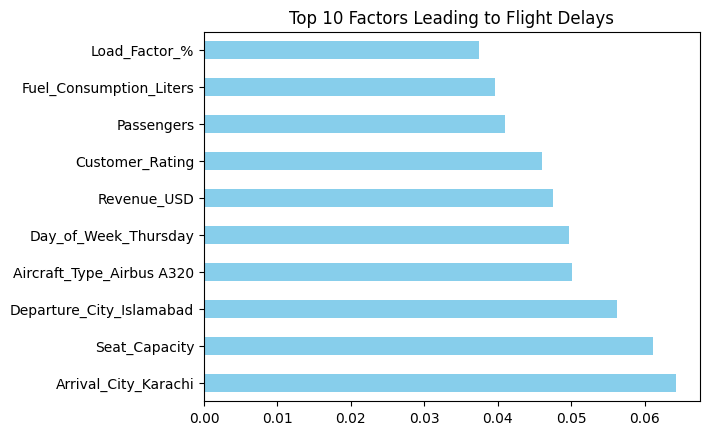

In [ ]:
import matplotlib.pyplot as plt

# Replace 'model' with your actual model variable name (e.g., rf, xgb, etc.)
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='skyblue')
plt.title('Top 10 Factors Leading to Flight Delays')
plt.show()

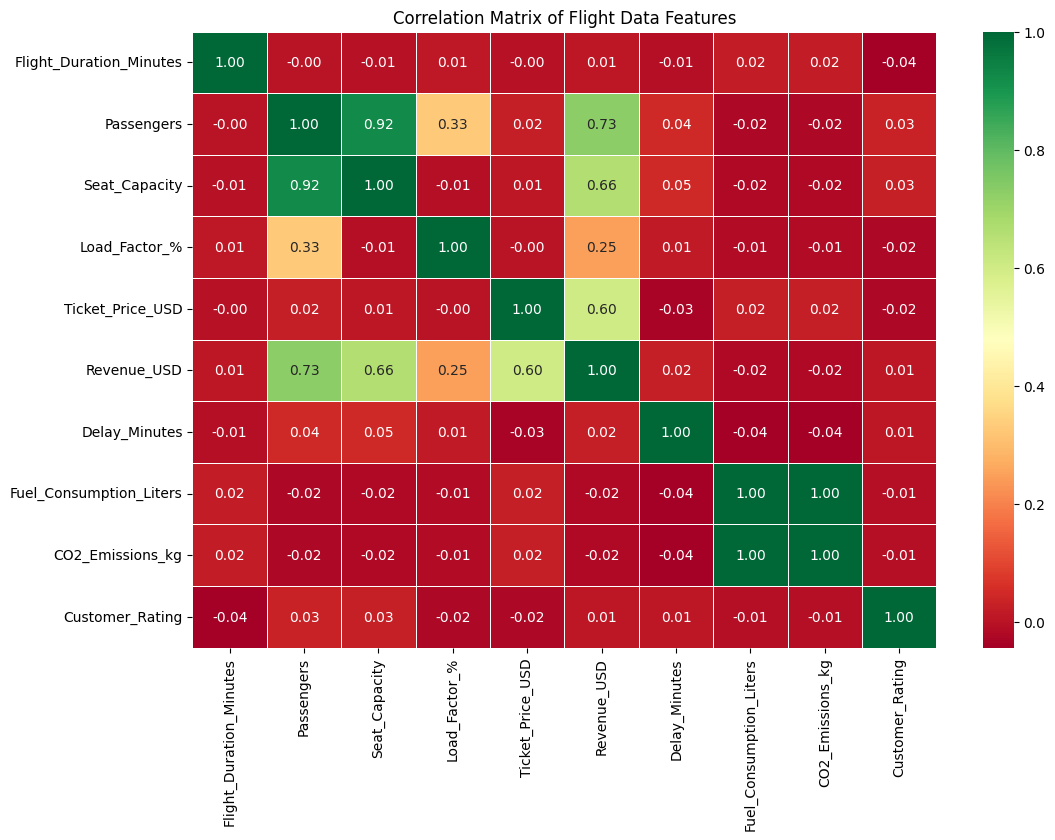

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use select_dtypes to filter for numeric columns only to avoid the ValueError
numeric_df = df.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# Create the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Flight Data Features')
plt.show()